# Exploratory Data Analysis (EDA)

This notebook explores the credit card transaction dataset to identify patterns in fraudulent activity.

### Objectives:
- Understand data distribution
- Analyze fraud vs normal transactions
- Identify key patterns in amount and time

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load Dataset

In [2]:
train_df = pd.read_csv("../data/raw/fraudTrain.csv")
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Dataset Overview

In [3]:
train_df.shape

(1296675, 23)

In [4]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [5]:
train_df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

## Fraud Distribution

Fraud transactions are extremely rare compared to normal transactions.

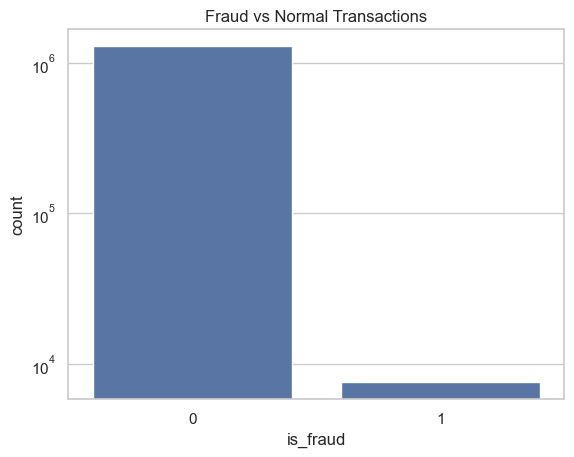

In [6]:
sns.countplot(x="is_fraud", data=train_df)
plt.yscale("log")
plt.title("Fraud vs Normal Transactions")
plt.show()

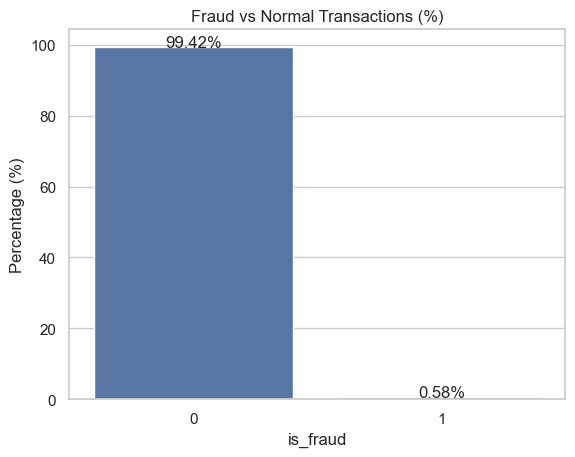

In [7]:
counts = train_df["is_fraud"].value_counts(normalize=True) * 100
sns.barplot(x=counts.index, y=counts.values)
plt.ylabel("Percentage (%)")
plt.title("Fraud vs Normal Transactions (%)")
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center')
plt.show()

## Transaction Amount Distribution

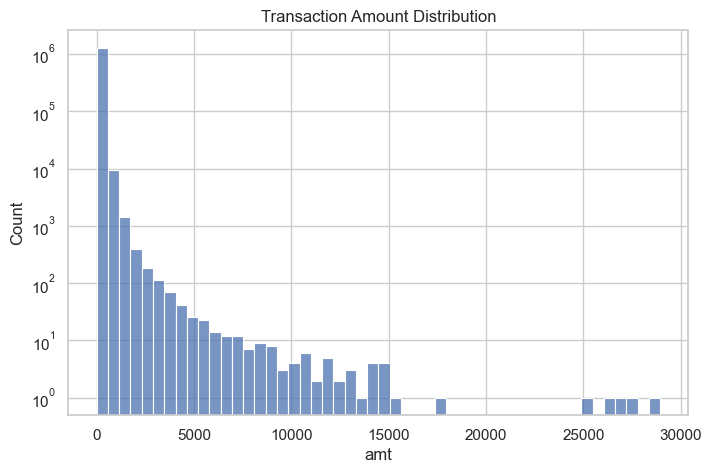

In [8]:
plt.figure(figsize=(8,5))
plt.yscale("log")
sns.histplot(train_df["amt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

## Insight

Most transactions are small, but fraud transactions tend to involve higher amounts.

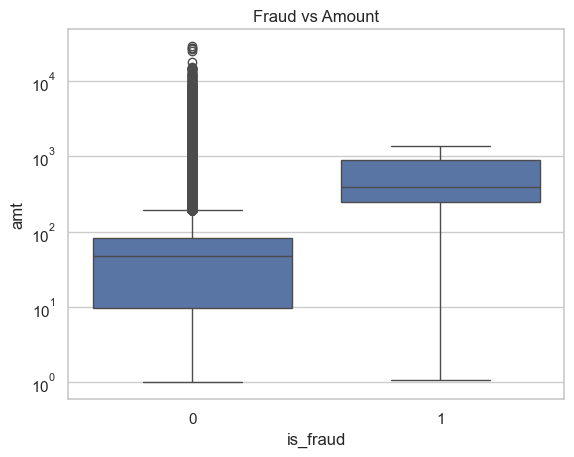

In [9]:
sns.boxplot(x="is_fraud", y="amt", data=train_df)
plt.yscale("log")
plt.title("Fraud vs Amount")
plt.show()

## Time-Based Analysis

In [10]:
train_df["trans_date_trans_time"] = pd.to_datetime(train_df["trans_date_trans_time"])
train_df["hour"] = train_df["trans_date_trans_time"].dt.hour

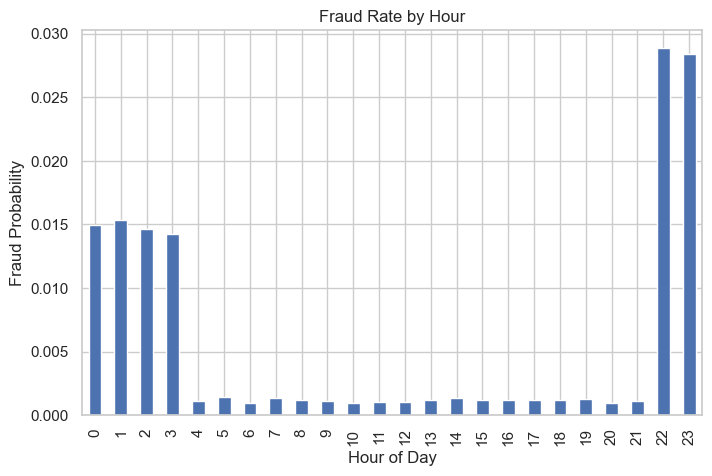

In [11]:
fraud_rate = train_df.groupby("hour")["is_fraud"].mean()
plt.figure(figsize=(8,5))
fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Probability")
plt.xlabel("Hour of Day")
plt.show()